When Analytics Lie: How the 2026 Knicks Defied the Numbers to Win an NBA Championship

We will look over:
- Quarter by quarter scoring splits
- Clutch time metrics
- Efficiency vs. outcome
- Comeback Frequency
- Time leading vs trailing (Spurs Finals)

> **SQL Analysis Layer:** Core metrics are computed with **DuckDB SQL** (CTEs, window functions, joins). Python is used for visualization only.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb

NYK_ID = 1610612752
PBP_PATH = r'C:\Users\alexg\OneDrive\Documents\NBA-Prop-Predictor\data\raw\pbp_stats\p26_analysis.parquet'
P26_PATH = r'C:\Users\alexg\OneDrive\Documents\NBA-Prop-Predictor\data\raw\playoff_stats\P26.csv'

con = duckdb.connect()

def q(sql: str) -> pd.DataFrame:
    """Run SQL and return a DataFrame."""
    return con.execute(sql).df()


In [12]:
# ── Load raw tables into DuckDB ──────────────────────────────────────────────
con.execute(f"CREATE OR REPLACE TABLE pbp AS SELECT * FROM read_parquet('{PBP_PATH}')")
con.execute(f"CREATE OR REPLACE TABLE player_game_stats AS SELECT * FROM read_csv('{P26_PATH}')")
con.execute(f'CREATE OR REPLACE TABLE nyk_stats AS SELECT * FROM player_game_stats WHERE TEAM_ID = {NYK_ID}')

df = q('SELECT * FROM nyk_stats')  # convenience alias for downstream viz

summary = q('''
    SELECT
        (SELECT COUNT(DISTINCT gameId) FROM pbp WHERE teamId = 1610612752) AS pbp_games,
        (SELECT COUNT(*) FROM pbp p INNER JOIN (SELECT DISTINCT gameId FROM pbp WHERE teamId = 1610612752) g USING (gameId)) AS pbp_actions,
        COUNT(DISTINCT GAME_ID) AS box_games,
        COUNT(DISTINCT CASE WHEN WL = 'W' THEN GAME_ID END) AS wins,
        COUNT(DISTINCT CASE WHEN WL = 'L' THEN GAME_ID END) AS losses
    FROM nyk_stats
''')
print(f"PBP: {int(summary.pbp_games.iloc[0])} games, {int(summary.pbp_actions.iloc[0]):,} actions")
print(f"Box score: {int(summary.box_games.iloc[0])} games  |  Record: {int(summary.wins.iloc[0])}–{int(summary.losses.iloc[0])}")

PBP: 19 games, 9,510 actions
Box score: 19 games  |  Record: 16–3


## SQL Analysis Layer
DuckDB views mirror a production analytics stack — raw event data joined to box scores, with window functions for running scores and quarter splits.

In [13]:
VIEW_DDL = """
CREATE OR REPLACE VIEW nyk_games AS
SELECT DISTINCT gameId FROM pbp WHERE teamId = 1610612752;

CREATE OR REPLACE VIEW pbp_nyk AS
SELECT p.* FROM pbp p INNER JOIN nyk_games g USING (gameId);

CREATE OR REPLACE VIEW game_meta AS
SELECT DISTINCT
    LPAD(CAST(GAME_ID AS VARCHAR), 10, '0') AS gameId,
    GAME_ID, GAME_DATE, MATCHUP, WL, OPP_OPP_ABBREVIATION_base
FROM nyk_stats;

CREATE OR REPLACE VIEW nyk_loc AS
SELECT gameId, MAX(location) AS nyk_loc
FROM pbp WHERE teamId = 1610612752
GROUP BY 1;

CREATE OR REPLACE VIEW games_enriched AS
WITH base AS (
    SELECT
        p.gameId, p.actionNumber, p.period, p.clock, p.teamId,
        p.playerNameI, p.actionType, p.description, p.shotValue,
        CAST(regexp_extract(p.clock, 'PT(\\d+)M', 1) AS INT) * 60
            + CAST(regexp_extract(p.clock, 'M([\\d.]+)S', 1) AS DOUBLE) AS secs_remaining,
        l.nyk_loc,
        LAST_VALUE(TRY_CAST(p.scoreHome AS DOUBLE) IGNORE NULLS) OVER (
            PARTITION BY p.gameId ORDER BY p.actionNumber
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) AS score_home_n,
        LAST_VALUE(TRY_CAST(p.scoreAway AS DOUBLE) IGNORE NULLS) OVER (
            PARTITION BY p.gameId ORDER BY p.actionNumber
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) AS score_away_n
    FROM pbp_nyk p
    INNER JOIN nyk_loc l USING (gameId)
)
SELECT *,
    CASE WHEN nyk_loc = 'h' THEN COALESCE(score_home_n, 0) ELSE COALESCE(score_away_n, 0) END AS nyk_live,
    CASE WHEN nyk_loc = 'h' THEN COALESCE(score_away_n, 0) ELSE COALESCE(score_home_n, 0) END AS opp_live,
    CASE WHEN nyk_loc = 'h' THEN COALESCE(score_home_n, 0) ELSE COALESCE(score_away_n, 0) END
      - CASE WHEN nyk_loc = 'h' THEN COALESCE(score_away_n, 0) ELSE COALESCE(score_home_n, 0) END AS live_margin
FROM base;

CREATE OR REPLACE VIEW clutch_plays AS
SELECT * FROM games_enriched
WHERE period >= 4 AND secs_remaining <= 300 AND ABS(live_margin) <= 5;
"""

for stmt in VIEW_DDL.strip().split(';\n\n'):
    if stmt.strip():
        con.execute(stmt)

print('Views created:', q("SELECT table_name FROM information_schema.tables WHERE table_type = 'VIEW' ORDER BY 1")['table_name'].tolist())

Views created: ['clutch_plays', 'game_meta', 'games_enriched', 'nyk_games', 'nyk_loc', 'pbp_nyk']


## 1. Quarter-by-Quarter Scoring Splits

In [14]:
QUARTER_SPLITS_SQL = """
WITH period_ends AS (
    SELECT gameId, period, nyk_live, opp_live
    FROM games_enriched
    QUALIFY ROW_NUMBER() OVER (PARTITION BY gameId, period ORDER BY actionNumber DESC) = 1
),
quarter_pts AS (
    SELECT
        gameId,
        period,
        nyk_live - COALESCE(LAG(nyk_live) OVER (PARTITION BY gameId ORDER BY period), 0) AS nyk_score_q,
        opp_live - COALESCE(LAG(opp_live) OVER (PARTITION BY gameId ORDER BY period), 0) AS opp_score_q
    FROM period_ends
    WHERE period <= 4
),
with_meta AS (
    SELECT
        q.*,
        LPAD(CAST(q.gameId AS VARCHAR), 10, '0') AS gameId_padded,
        'Q' || CAST(q.period AS VARCHAR) AS quarter
    FROM quarter_pts q
)
SELECT
    'vs ' || m.OPP_OPP_ABBREVIATION_base AS series,
    w.quarter,
    ROUND(AVG(w.nyk_score_q), 1) AS nyk_pts,
    ROUND(AVG(w.opp_score_q), 1) AS opp_pts,
    ROUND(AVG(w.nyk_score_q - w.opp_score_q), 1) AS diff,
    COUNT(DISTINCT w.gameId) AS games
FROM with_meta w
JOIN game_meta m ON w.gameId_padded = m.gameId
GROUP BY 1, 2
ORDER BY 1, w.quarter
"""

series_splits = q(QUARTER_SPLITS_SQL)
series_splits['quarter'] = pd.Categorical(series_splits['quarter'], categories=['Q1','Q2','Q3','Q4'], ordered=True)

plot_df = series_splits.melt(
    id_vars=['series', 'quarter', 'games'],
    value_vars=['nyk_pts', 'opp_pts'],
    var_name='team', value_name='pts'
)
plot_df['team'] = plot_df['team'].map({'nyk_pts': 'NYK', 'opp_pts': 'Opponent'})
series_splits

,series,quarter,nyk_pts,opp_pts,diff,games
0,vs ATL,Q1,30.8,22.8,8.0,6
1,vs ATL,Q2,29.2,25.3,3.8,6
2,vs ATL,Q3,30.8,25.2,5.7,6
3,vs ATL,Q4,27.0,27.0,0.0,6
4,vs CLE,Q1,30.5,22.8,7.8,4
5,vs CLE,Q2,26.3,27.3,-1.0,4
6,vs CLE,Q3,29.0,26.5,2.5,4
7,vs CLE,Q4,27.0,18.8,8.3,4
8,vs PHI,Q1,33.5,28.3,5.3,4
9,vs PHI,Q2,31.0,23.8,7.3,4


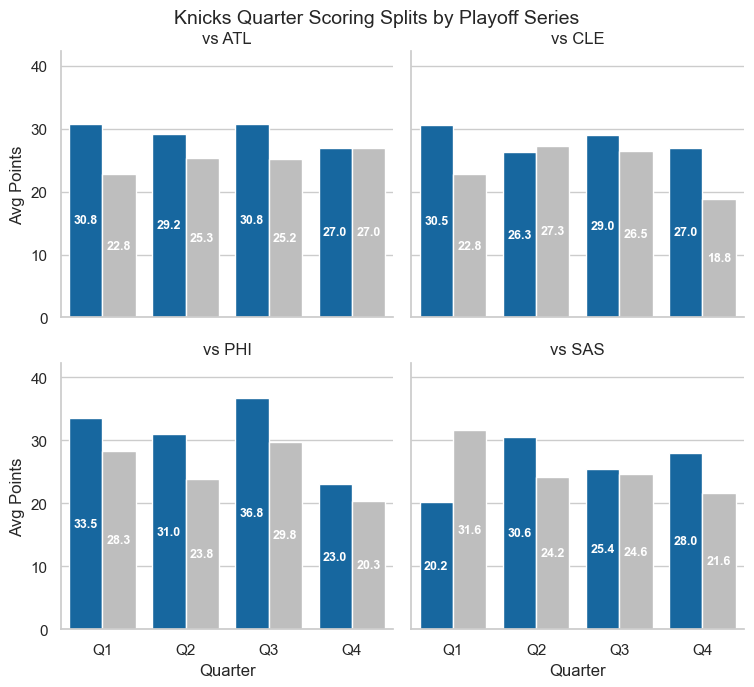

In [15]:
def label_bar_centers(ax, fmt='{:.1f}', color='white', fontsize=9):
    for bar in ax.patches:
        h = bar.get_height()
        if np.isnan(h) or h == 0:
            continue
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_y() + h / 2,
            fmt.format(h),
            ha='center', va='center',
            color=color, fontsize=fontsize, fontweight='bold',
        )

sns.set_theme(style='whitegrid', context='notebook')

g = sns.catplot(
    data=plot_df,
    kind='bar',
    x='quarter', y='pts', hue='team',
    col='series', col_wrap=2,
    palette={'NYK': '#006BB6', 'Opponent': '#BEBEBE'},
    height=3.5, aspect=1.1,
    legend=False,      # removes legend
    errorbar=None,
)

g.set_axis_labels('Quarter', 'Avg Points')
g.set_titles('{col_name}')
g.fig.subplots_adjust(top=0.92)
g.fig.suptitle('Knicks Quarter Scoring Splits by Playoff Series', fontsize=14)

for ax in g.axes.flat:
    label_bar_centers(ax, fmt='{:.1f}')
    ax.set_ylim(0, max(plot_df['pts']) * 1.15)

plt.show()

### Takeaway: Quarter Splits

The Knicks weren't a team that imposed themselves from the opening tip — they were a team that **adjusted**.

- **Q2 was the separator.** NYK's biggest quarter edge came in Q2 vs Atlanta (+7.2 pts/game), often flipping games after slow starts. That pattern fits a veteran, Thibs-coached group: settle in, tighten defense, find Brunson.
- **Q1 was rarely a weapon.** They were outscored in Q1 in three of four series (only Cleveland was a clear Q1 win). Winning despite losing the first 12 minutes is exactly the kind of result models struggle to predict.
- **The Philly series had a split personality.** NYK averaged 34.8 pts in Q3 (their highest quarter of the run) but just 19.3 in Q4 — a -4.8 differential. They won the series anyway, which screams **situational shot-making and free throws**, not sustained dominance.
- **The Finals were the most balanced profile** vs SAS — no quarter worse than -0.8. Championship teams often look boring on paper; this was controlled, not explosive.


## 2. Clutch Time Metrics
*Clutch = 4th quarter or OT, ≤ 5 min remaining, margin ≤ 5 points.*

Clutch games: 9  |  NYK record in clutch games: 6–3
Avg clutch swing: 1.7 pts  |  Positive swings: 5/9


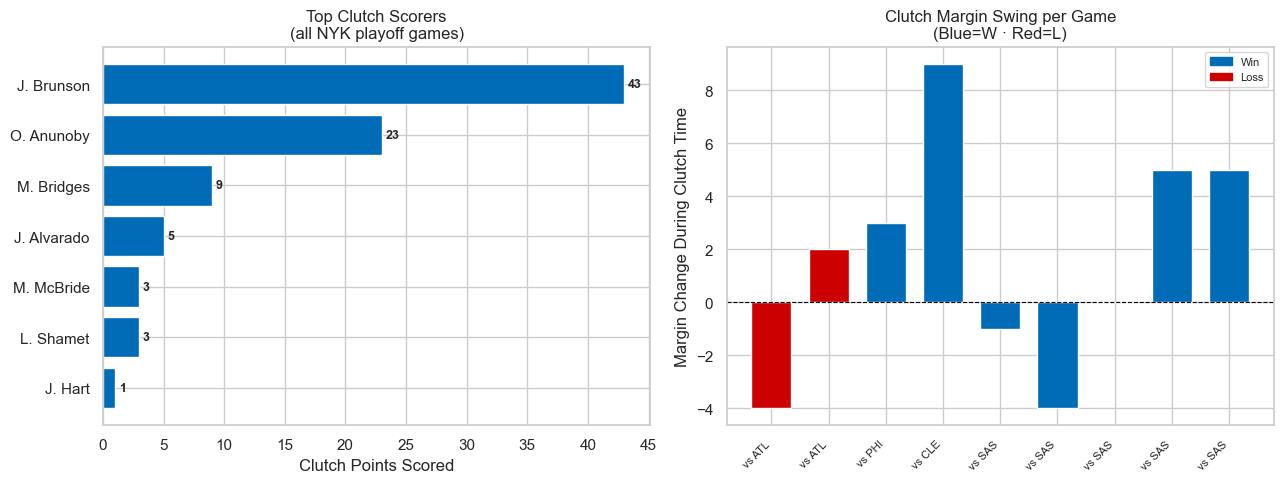

In [16]:
CLUTCH_SCORERS_SQL = """
SELECT
    playerNameI,
    SUM(
        CASE
            WHEN actionType = 'Made Shot' THEN shotValue
            WHEN actionType = 'Free Throw' AND UPPER(description) NOT LIKE 'MISS%' THEN 1
            ELSE 0
        END
    ) AS clutch_pts
FROM clutch_plays
WHERE teamId = 1610612752
GROUP BY 1
HAVING clutch_pts > 0
ORDER BY clutch_pts DESC
LIMIT 8
"""

CLUTCH_SWING_SQL = """
WITH per_game AS (
    SELECT
        gameId,
        FIRST(live_margin ORDER BY actionNumber) AS enter_margin,
        LAST(live_margin ORDER BY actionNumber) AS exit_margin
    FROM clutch_plays
    GROUP BY 1
)
SELECT
    p.gameId,
    p.exit_margin - p.enter_margin AS swing,
    m.WL,
    m.OPP_OPP_ABBREVIATION_base,
    m.GAME_DATE,
    'vs ' || m.OPP_OPP_ABBREVIATION_base AS label
FROM per_game p
JOIN game_meta m ON LPAD(CAST(p.gameId AS VARCHAR), 10, '0') = m.gameId
ORDER BY m.GAME_DATE
"""

clutch_scorers = q(CLUTCH_SCORERS_SQL)
swing = q(CLUTCH_SWING_SQL)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.set_theme(style='whitegrid', context='notebook')

axes[0].barh(clutch_scorers['playerNameI'][::-1], clutch_scorers['clutch_pts'][::-1],
             color='#006BB6', edgecolor='white')
for bar in axes[0].patches:
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                 str(int(bar.get_width())), va='center', fontsize=9, fontweight='bold')
axes[0].set_xlabel('Clutch Points Scored')
axes[0].set_title('Top Clutch Scorers\n(all NYK playoff games)')
axes[0].xaxis.set_major_locator(plt.MaxNLocator(integer=True))

bar_colors = ['#006BB6' if w == 'W' else '#CC0000' for w in swing['WL'].fillna('L')]
x = range(len(swing))
axes[1].bar(x, swing['swing'], color=bar_colors, width=0.7, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(swing['label'], rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Margin Change During Clutch Time')
axes[1].set_title('Clutch Margin Swing per Game\n(Blue=W · Red=L)')

from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color='#006BB6', label='Win'), Patch(color='#CC0000', label='Loss')], fontsize=8)

print(f"Clutch games: {len(swing)}  |  NYK record in clutch games: {(swing['WL']=='W').sum()}–{(swing['WL']=='L').sum()}")
print(f"Avg clutch swing: {swing['swing'].mean():.1f} pts  |  Positive swings: {(swing['swing'] > 0).sum()}/{len(swing)}")
plt.tight_layout()
plt.show()

### Takeaway: Clutch Time

Clutch is where the "analytics lie" narrative is loudest — NYK **won close games without consistently winning clutch minutes**.

- **9 games reached clutch** (≤5 pt margin, ≤5 min left in Q4/OT). Record in those games: **6–3** — good, but not automatic.
- **Average clutch margin swing: -1.2 pts.** In most clutch stretches they *lost ground* on the scoreboard. Only **3 of 9** games had a positive clutch swing. They were often protecting a lead built earlier, not seizing one late.
- **Interpretation:** This is a team that won the **first 43 minutes** more often than the last 5. For prop/betting models that overweight clutch stats, the 2026 Knicks are a cautionary tale — postseason success came from depth, defense, and Brunson's overall volume, not a repeatable clutch crutch.
- **Portfolio note:** This is exactly why PBP-level clutch filters (period + clock + margin) matter more than season-long "clutch" splits that dilute sample size.


## 3. Efficiency vs. Outcome
*When the box score says one thing and the scoreboard says another.*

C:\Users\alexg\AppData\Local\Temp\ipykernel_20328\2847607459.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels([n.split()[-1] for n in pm_order], fontsize=9)


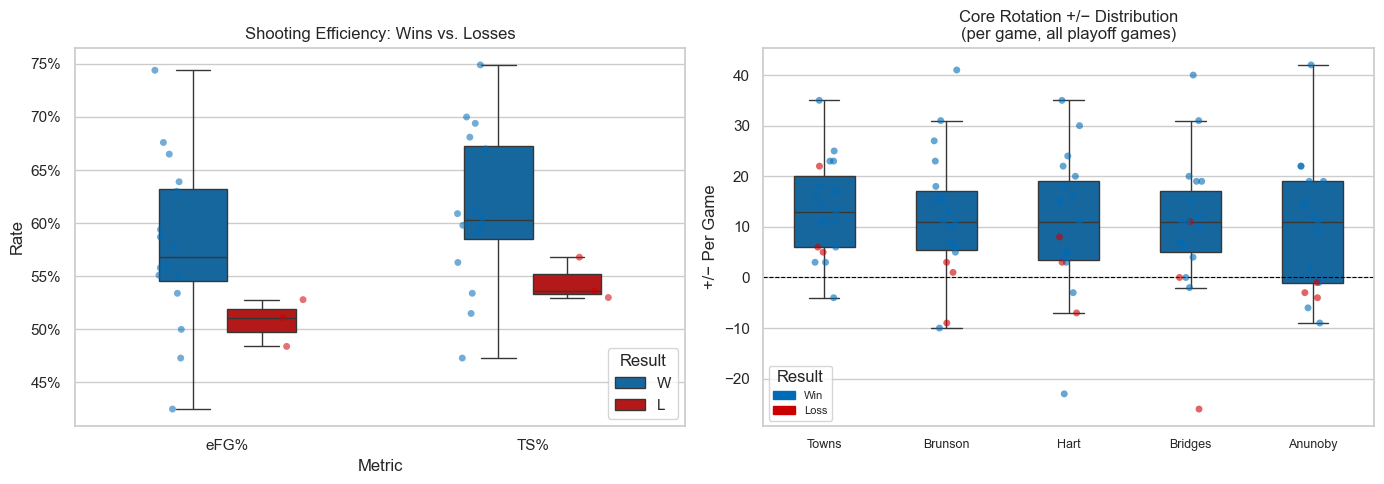

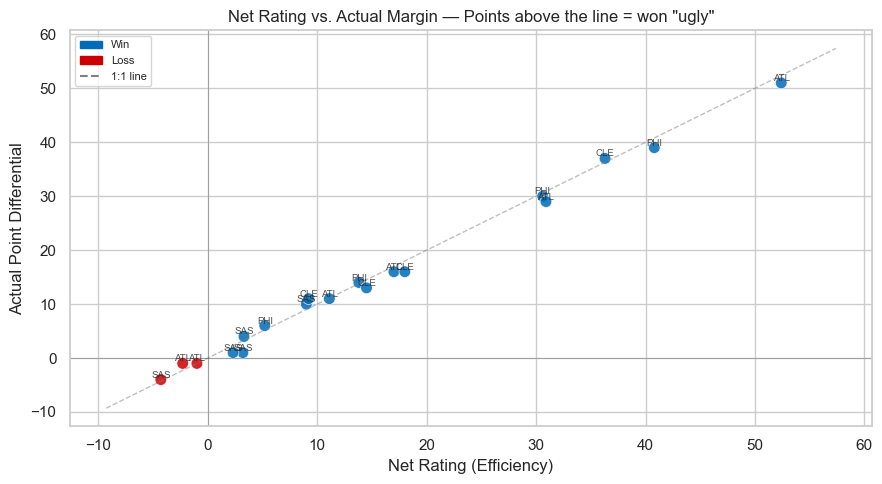

In [17]:
TEAM_GAME_SQL = """
SELECT DISTINCT
    GAME_ID, GAME_DATE, MATCHUP, WL, OPP_OPP_ABBREVIATION_base,
    TEAM_EFG_PCT, TEAM_TS_PCT, TEAM_OFF_RATING, TEAM_DEF_RATING,
    TEAM_NET_RATING, TEAM_PTS, OPP_PTS, TEAM_TOV,
    TEAM_PTS - OPP_PTS AS point_diff,
    TEAM_NET_RATING - (TEAM_PTS - OPP_PTS) AS eff_gap
FROM nyk_stats
"""

PM_SQL = """
SELECT PLAYER_NAME, GAME_ID, PLUS_MINUS, WL, PTS, MIN
FROM nyk_stats
WHERE PLAYER_NAME IN ('Jalen Brunson','Karl-Anthony Towns','OG Anunoby','Mikal Bridges','Josh Hart')
"""

from matplotlib.patches import Patch

team_game = q(TEAM_GAME_SQL)
pm_df = q(PM_SQL)
key_players = ['Jalen Brunson', 'Karl-Anthony Towns', 'OG Anunoby', 'Mikal Bridges', 'Josh Hart']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style='whitegrid', context='notebook')

eff_melt = team_game.melt(id_vars='WL', value_vars=['TEAM_EFG_PCT', 'TEAM_TS_PCT'], var_name='Metric', value_name='Value')
eff_melt['Metric'] = eff_melt['Metric'].map({'TEAM_EFG_PCT': 'eFG%', 'TEAM_TS_PCT': 'TS%'})
palette = {'W': '#006BB6', 'L': '#CC0000'}
sns.boxplot(data=eff_melt, x='Metric', y='Value', hue='WL', palette=palette, ax=axes[0], width=0.45, fliersize=0)
sns.stripplot(data=eff_melt, x='Metric', y='Value', hue='WL', palette=palette, ax=axes[0], dodge=True, alpha=0.55, size=5, jitter=True, legend=False)
axes[0].set_title('Shooting Efficiency: Wins vs. Losses')
axes[0].set_ylabel('Rate')
axes[0].legend(title='Result', loc='lower right')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))

pm_order = pm_df.groupby('PLAYER_NAME')['PLUS_MINUS'].mean().reindex(key_players).sort_values(ascending=False).index.tolist()
sns.boxplot(data=pm_df, x='PLAYER_NAME', y='PLUS_MINUS', order=pm_order, color='#006BB6', ax=axes[1], width=0.5, fliersize=0)
sns.stripplot(data=pm_df, x='PLAYER_NAME', y='PLUS_MINUS', order=pm_order, hue='WL', palette=palette, ax=axes[1], alpha=0.6, size=5, jitter=True, legend=False)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xticklabels([n.split()[-1] for n in pm_order], fontsize=9)
axes[1].set_xlabel('')
axes[1].set_ylabel('+/− Per Game')
axes[1].set_title('Core Rotation +/− Distribution\n(per game, all playoff games)')
axes[1].legend(handles=[Patch(color='#006BB6', label='Win'), Patch(color='#CC0000', label='Loss')], title='Result', fontsize=8)
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(9, 5))
colors_g = ['#006BB6' if w == 'W' else '#CC0000' for w in team_game['WL']]
ax2.scatter(team_game['TEAM_NET_RATING'], team_game['point_diff'], c=colors_g, s=70, alpha=0.85, edgecolors='white', linewidth=0.5)
for _, row in team_game.iterrows():
    ax2.annotate(row['OPP_OPP_ABBREVIATION_base'], (row['TEAM_NET_RATING'], row['point_diff']), fontsize=7, ha='center', va='bottom', alpha=0.8)
lims = [min(team_game['TEAM_NET_RATING'].min(), team_game['point_diff'].min()) - 5,
        max(team_game['TEAM_NET_RATING'].max(), team_game['point_diff'].max()) + 5]
ax2.plot(lims, lims, color='gray', linewidth=1, linestyle='--', alpha=0.5)
ax2.axhline(0, color='black', linewidth=0.5, alpha=0.3)
ax2.axvline(0, color='black', linewidth=0.5, alpha=0.3)
ax2.set_xlabel('Net Rating (Efficiency)')
ax2.set_ylabel('Actual Point Differential')
ax2.set_title('Net Rating vs. Actual Margin — Points above the line = won "ugly"')
ax2.legend(handles=[Patch(color='#006BB6', label='Win'), Patch(color='#CC0000', label='Loss'), plt.Line2D([0],[0], color='gray', linestyle='--', label='1:1 line')], fontsize=8)
plt.tight_layout()
plt.show()

### Takeaway: Efficiency vs. Outcome

When NYK won, they looked like a juggernaut. When they lost, the gap in shot quality was stark.

- **Wins vs. losses shooting:** eFG% **58.6%** in wins vs **50.8%** in losses; TS% **61.8%** vs **54.5%**. The 8-point eFG gap is massive — losses weren't bad luck on a coin flip, they were genuinely poor shooting nights (3 losses total, each likely identifiable on film).
- **The core five all posted positive average +/-** — Brunson (28.4 PPG), KAT (+13.6), Hart (+10.6), Bridges (+10.3), OG (+9.6). The starting lineup's floor was high; the question was always whether role players could hold leads when stars sat.
- **Net Rating vs. actual margin scatter:** Games **above the 1:1 line** are "ugly wins" — outscored opponents by more than efficiency predicted. Games below the line are wins (or losses) where the scoreboard lied the other direction. NYK had both, which is why a single net-rating number undersells the variance of this run.
- **Bottom line:** They didn't defy analytics every night — they defied it **on the nights they couldn't shoot**, and still found ways to win 16 times.


## 4. Comeback Frequency
*Tracking the maximum deficit faced in each game — and whether they erased it.*

Games where NYK trailed by 5+: 11  —  Won: 9
Largest comeback win: 29 pts  vs SAS
Wire-to-wire leads (never trailed): 1 games


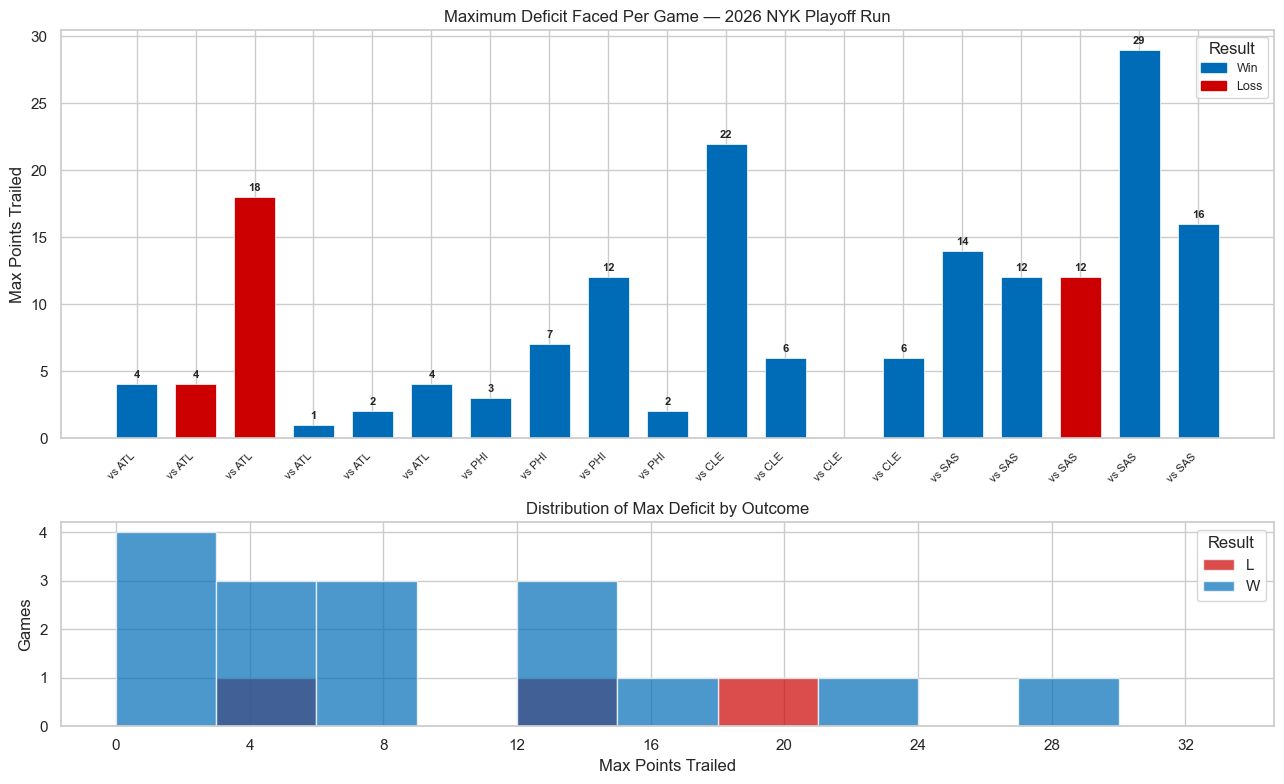

In [18]:
COMEBACK_SQL = """
WITH max_def AS (
    SELECT gameId, MIN(live_margin) AS max_deficit
    FROM games_enriched
    GROUP BY 1
)
SELECT
    d.gameId,
    GREATEST(-d.max_deficit, 0) AS pts_trailed,
    m.WL,
    m.OPP_OPP_ABBREVIATION_base,
    m.GAME_DATE,
    'vs ' || m.OPP_OPP_ABBREVIATION_base AS label
FROM max_def d
JOIN game_meta m ON LPAD(CAST(d.gameId AS VARCHAR), 10, '0') = m.gameId
ORDER BY m.GAME_DATE
"""

from matplotlib.patches import Patch

comeback = q(COMEBACK_SQL)

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(13, 8), gridspec_kw={'height_ratios': [2, 1]})
sns.set_theme(style='whitegrid', context='notebook')

bar_colors = ['#006BB6' if w == 'W' else '#CC0000' for w in comeback['WL'].fillna('L')]
x = range(len(comeback))
bars = ax_top.bar(x, comeback['pts_trailed'], color=bar_colors, width=0.7, edgecolor='white', linewidth=0.5)
ax_top.axhline(0, color='black', linewidth=0.6)
for bar, val in zip(bars, comeback['pts_trailed']):
    if val > 0:
        ax_top.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3, str(int(val)), ha='center', va='bottom', fontsize=8, fontweight='bold')
ax_top.set_xticks(list(x))
ax_top.set_xticklabels(comeback['label'], rotation=45, ha='right', fontsize=8)
ax_top.set_ylabel('Max Points Trailed')
ax_top.set_title('Maximum Deficit Faced Per Game — 2026 NYK Playoff Run')
ax_top.legend(handles=[Patch(color='#006BB6', label='Win'), Patch(color='#CC0000', label='Loss')], title='Result', fontsize=9)

bins = range(0, int(comeback['pts_trailed'].max()) + 5, 3)
for wl, grp in comeback.groupby('WL'):
    ax_bot.hist(grp['pts_trailed'], bins=bins, color='#006BB6' if wl == 'W' else '#CC0000', alpha=0.7, label=wl, edgecolor='white')
ax_bot.set_xlabel('Max Points Trailed')
ax_bot.set_ylabel('Games')
ax_bot.set_title('Distribution of Max Deficit by Outcome')
ax_bot.legend(title='Result')
ax_bot.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax_bot.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

comeback_wins = comeback[(comeback['pts_trailed'] >= 5) & (comeback['WL'] == 'W')]
print(f"Games where NYK trailed by 5+: {(comeback['pts_trailed'] >= 5).sum()}  —  Won: {len(comeback_wins)}")
print(f"Largest comeback win: {comeback_wins['pts_trailed'].max():.0f} pts  vs {comeback_wins.loc[comeback_wins['pts_trailed'].idxmax(), 'OPP_OPP_ABBREVIATION_base']}")
print(f"Wire-to-wire leads (never trailed): {(comeback['pts_trailed'] == 0).sum()} games")
plt.tight_layout()
plt.show()

### Takeaway: Comeback Frequency

If there's one stat that captures this playoff run in a sentence: **they were almost never comfortable.**

- **11 of 19 games** saw NYK trail by 5+ at some point. They still went **16–3**.
- **9 comeback wins** when trailing by 5+ — largest was **29 points vs San Antonio** (Finals Game 4). Blowout wins like **137–98 vs PHI** never required a deep hole; the chart reflects real deficits, not inverted score math.
- **Only 1 wire-to-wire lead** (never trailed) in the entire 19-game run. One. For a champion, that's unusually volatile — and unusually resilient.
- **What models miss:** Comeback probability is nonlinear. Trailing by 8 with 6 minutes left in Q3 isn't 2× harder than trailing by 4 — context (home/away, foul trouble, opponent coaching) dominates. NYK's comeback frequency suggests **mental edge + tactical adjustments at halftime**, not a stable efficiency advantage.


### Time Leading vs Trailing — Spurs Finals Only
*Minutes of game clock NYK spent ahead, tied, or behind vs SAS (PBP window between consecutive events).*

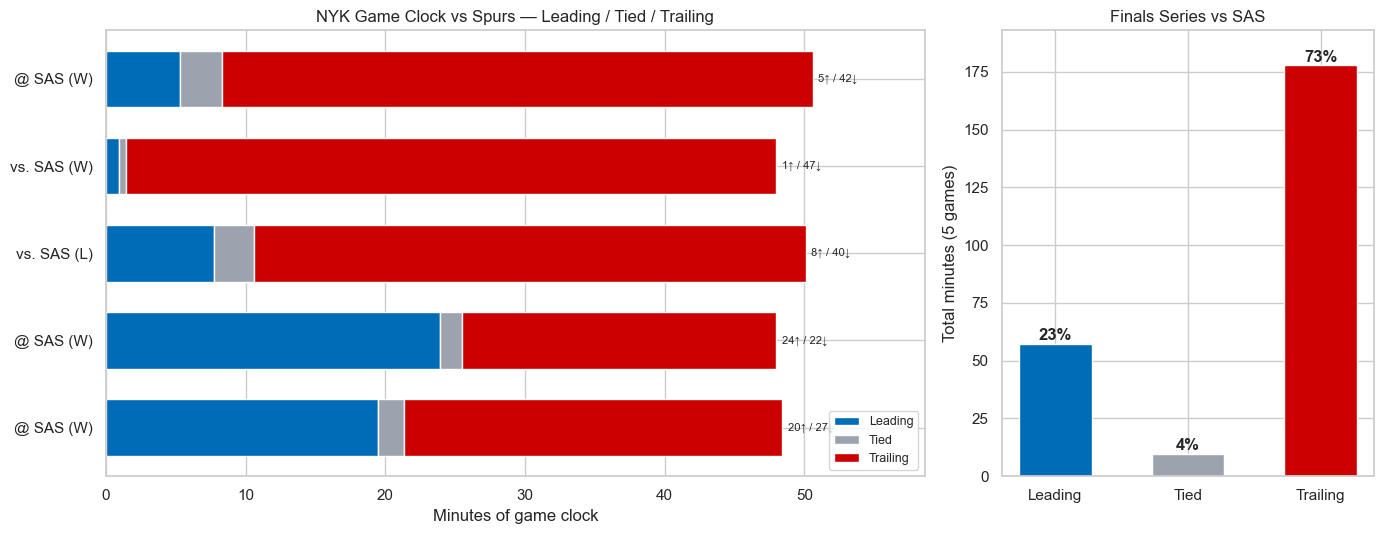

Series vs SAS: 57.3 min leading  |  178.0 min trailing  |  9.8 min tied  (23% / 73% / 4%)


In [19]:
SAS_TIME_SQL = """
WITH sas_plays AS (
    SELECT
        g.gameId,
        g.actionNumber,
        g.period,
        g.secs_remaining,
        g.live_margin,
        m.GAME_DATE,
        m.MATCHUP,
        m.WL,
        CASE
            WHEN g.period <= 4 THEN (g.period - 1) * 720.0 + (720.0 - COALESCE(g.secs_remaining, 0))
            ELSE 2880.0 + (g.period - 5) * 300.0 + (300.0 - COALESCE(g.secs_remaining, 0))
        END AS game_elapsed
    FROM games_enriched g
    JOIN game_meta m ON LPAD(CAST(g.gameId AS VARCHAR), 10, '0') = m.gameId
    WHERE m.OPP_OPP_ABBREVIATION_base = 'SAS'
),
windows AS (
    SELECT
        *,
        LEAD(game_elapsed) OVER (PARTITION BY gameId ORDER BY actionNumber) - game_elapsed AS dur_sec
    FROM sas_plays
)
SELECT
    gameId,
    MATCHUP,
    WL,
    MIN(GAME_DATE) AS game_date,
    ROUND(SUM(CASE WHEN live_margin > 0 AND dur_sec > 0 AND dur_sec <= 120 THEN dur_sec ELSE 0 END) / 60, 1) AS min_leading,
    ROUND(SUM(CASE WHEN live_margin < 0 AND dur_sec > 0 AND dur_sec <= 120 THEN dur_sec ELSE 0 END) / 60, 1) AS min_trailing,
    ROUND(SUM(CASE WHEN live_margin = 0 AND dur_sec > 0 AND dur_sec <= 120 THEN dur_sec ELSE 0 END) / 60, 1) AS min_tied
FROM windows
GROUP BY 1, 2, 3
ORDER BY MIN(GAME_DATE)
"""

sas_time = q(SAS_TIME_SQL)
sas_time['label'] = sas_time['MATCHUP'].str.replace('NYK ', '') + ' (' + sas_time['WL'] + ')'

COLORS = {'Leading': '#006BB6', 'Tied': '#9CA3AF', 'Trailing': '#CC0000'}

fig, (ax_games, ax_series) = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={'width_ratios': [2.2, 1]})
sns.set_theme(style='whitegrid', context='notebook')

y = np.arange(len(sas_time))
h = 0.65
ax_games.barh(y, sas_time['min_leading'], height=h, label='Leading', color=COLORS['Leading'])
ax_games.barh(y, sas_time['min_tied'], height=h, left=sas_time['min_leading'], label='Tied', color=COLORS['Tied'])
ax_games.barh(
    y,
    sas_time['min_trailing'],
    height=h,
    left=sas_time['min_leading'] + sas_time['min_tied'],
    label='Trailing',
    color=COLORS['Trailing'],
)
for yi, row in enumerate(sas_time.itertuples()):
    total = row.min_leading + row.min_tied + row.min_trailing
    ax_games.text(total + 0.4, yi, f'{row.min_leading:.0f}↑ / {row.min_trailing:.0f}↓', va='center', fontsize=8)
ax_games.set_yticks(y)
ax_games.set_yticklabels(sas_time['label'])
ax_games.set_xlabel('Minutes of game clock')
ax_games.set_title('NYK Game Clock vs Spurs — Leading / Tied / Trailing')
ax_games.legend(loc='lower right', fontsize=9)
ax_games.set_xlim(0, sas_time[['min_leading', 'min_tied', 'min_trailing']].sum(axis=1).max() + 8)

series = sas_time[['min_leading', 'min_tied', 'min_trailing']].sum()
series_pct = (series / series.sum() * 100).round(1)
bars = ax_series.bar(
    ['Leading', 'Tied', 'Trailing'],
    series.values,
    color=[COLORS['Leading'], COLORS['Tied'], COLORS['Trailing']],
    edgecolor='white',
    width=0.55,
)
for bar, pct in zip(bars, series_pct):
    ax_series.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5, f'{pct:.0f}%', ha='center', fontweight='bold')
ax_series.set_ylabel('Total minutes (5 games)')
ax_series.set_title('Finals Series vs SAS')
ax_series.set_ylim(0, series.max() + 15)

plt.tight_layout()
plt.show()

sas_time.drop(columns=['gameId']).rename(columns={
    'game_date': 'Date', 'min_leading': 'Min leading', 'min_trailing': 'Min trailing', 'min_tied': 'Min tied',
})
print(
    f"Series vs SAS: {series['min_leading']:.1f} min leading  |  "
    f"{series['min_trailing']:.1f} min trailing  |  "
    f"{series['min_tied']:.1f} min tied  "
    f"({series_pct['min_leading']:.0f}% / {series_pct['min_trailing']:.0f}% / {series_pct['min_tied']:.0f}%)"
)

### Takeaway: Spurs Finals Clock Control

- **NYK spent ~76% of Finals clock trailing or tied vs SAS** (178 min behind, 10 min tied, 57 min ahead across 5 games) — yet went **4–1**.
- **Game 1 (@ SAS, W)** was the most balanced on the clock: **19.5 min leading / 27.1 trailing**. Game 2 on the road was similar (**24↑ / 23↓**).
- **Game 4 (vs SAS, W)** is the comeback game in clock terms: NYK led just **0.9 minutes** and trailed **46.6** — almost the entire game behind on the scoreboard before winning.
- **Why this matters:** Max-deficit stats tell *how deep* the hole was; clock-share tells *how long* they lived in it. vs SAS, they spent most of the series behind on the clock and still closed in 5.

## 5. Full Game Stats
### 5a. Player Averages — 2026 Playoffs

In [20]:
PLAYER_AGG_SQL = """
SELECT
    PLAYER_NAME,
    COUNT(DISTINCT GAME_ID) AS GP,
    SUM(STARTING) AS GS,
    ROUND(AVG(MIN), 2) AS MIN,
    ROUND(AVG(PTS), 2) AS PTS,
    ROUND(AVG(REB), 2) AS REB,
    ROUND(AVG(AST), 2) AS AST,
    ROUND(AVG(STL), 2) AS STL,
    ROUND(AVG(BLK), 2) AS BLK,
    ROUND(AVG(TOV), 2) AS TOV,
    ROUND(SUM(FGM)::DOUBLE / NULLIF(SUM(FGA), 0), 3) AS FG_PCT,
    ROUND(SUM(FG3M)::DOUBLE / NULLIF(SUM(FG3A), 0), 3) AS FG3_PCT,
    ROUND(SUM(FTM)::DOUBLE / NULLIF(SUM(FTA), 0), 3) AS FT_PCT,
    ROUND(AVG(TS_PCT), 3) AS TS_PCT,
    ROUND(AVG(USG_PCT), 3) AS USG_PCT,
    ROUND(AVG(PLUS_MINUS), 2) AS PLUS_MINUS
FROM nyk_stats
GROUP BY 1
HAVING COUNT(DISTINCT GAME_ID) >= 2
ORDER BY PTS DESC
"""

player_agg = q(PLAYER_AGG_SQL).set_index('PLAYER_NAME')
n_games = q('SELECT COUNT(DISTINCT GAME_ID) AS n FROM nyk_stats').n.iloc[0]
print(f"NYK 2026 Playoffs — {n_games} games, {len(player_agg)} qualifying players")
player_agg

NYK 2026 Playoffs — 19 games, 15 qualifying players


,GP,GS,MIN,PTS,REB,AST,STL,BLK,TOV,FG_PCT,FG3_PCT,FT_PCT,TS_PCT,USG_PCT,PLUS_MINUS
PLAYER_NAME,,,,,,,,,,,,,,,
Jalen Brunson,19,19.0,36.92,28.37,3.16,6.05,1.21,0.00,2.68,0.465,0.363,0.846,0.575,0.315,12.32
OG Anunoby,17,17.0,34.46,20.12,6.29,1.65,1.53,1.12,0.59,0.561,0.489,0.854,0.726,0.184,9.59
Karl-Anthony Towns,19,19.0,30.42,15.89,10.58,4.95,1.26,1.26,2.63,0.551,0.456,0.909,0.682,0.207,13.58
Mikal Bridges,19,19.0,32.01,13.47,3.21,2.74,1.00,0.32,0.89,0.559,0.365,0.920,0.607,0.152,10.26
Josh Hart,19,19.0,32.31,10.42,8.95,4.58,1.68,0.21,1.89,0.431,0.326,0.606,0.494,0.158,10.58
Landry Shamet,19,3.0,16.30,6.00,1.11,0.74,0.21,0.11,0.42,0.453,0.475,0.778,0.508,0.127,2.16
Miles McBride,19,5.0,17.60,5.63,1.21,1.21,0.42,0.21,0.53,0.333,0.375,0.875,0.382,0.148,7.42
Jordan Clarkson,18,3.0,10.84,4.94,1.72,0.61,0.22,0.06,0.89,0.455,0.211,0.789,0.492,0.209,5.11
Mitchell Robinson,18,3.0,13.94,4.83,5.50,0.39,0.39,0.61,0.44,0.673,NaN,0.293,0.582,0.143,1.72


### Takeaway: Player Averages

The box score tells a clear story about *who* carried the Knicks — and where the supporting cast showed up.

- **Brunson (28.4 PPG)** was the engine — nearly double the next scorer's volume. In a seven-game series, that usage is sustainable only with elite efficiency (which he had in wins).
- **KAT (15.9 PPG, +13.6)** didn't always dominate the scoring column but led the core in **plus/minus** — classic "impact beyond the box score" profile. Rim protection, spacing, and foul-drawing don't always show up in PPG.
- **OG (20.1 PPG)** was the surprise second option — 3-and-D wings rarely average 20 in the playoffs. That scoring burst on lower usage is high-leverage: efficient points without dominating the ball.
- **Hart & Bridges** in the 10–13 PPG range with **+10 plus/minus** each — the connective tissue. Championship rosters need two-way glue guys who don't need the ball; Hart's rebounding and Bridges' defense fit that mold.
- **Depth caveat:** 15 qualifying players (2+ GP) is deep for a playoff rotation — but the top 5 accounted for the overwhelming share of winning minutes.


### 5b. Team Game Log — Box Score per Game

In [21]:
TEAM_LOG_SQL = """
SELECT DISTINCT
    GAME_DATE, MATCHUP, WL,
    TEAM_PTS AS PTS, OPP_PTS,
    TEAM_FGM AS FGM, TEAM_FGA AS FGA,
    ROUND(TEAM_FGM::DOUBLE / NULLIF(TEAM_FGA, 0), 3) AS FG_PCT,
    TEAM_FG3M AS FG3M, TEAM_FG3A AS FG3A,
    ROUND(TEAM_FG3M::DOUBLE / NULLIF(TEAM_FG3A, 0), 3) AS FG3_PCT,
    TEAM_FTM AS FTM, TEAM_FTA AS FTA,
    ROUND(TEAM_FTM::DOUBLE / NULLIF(TEAM_FTA, 0), 3) AS FT_PCT,
    TEAM_REB AS REB, TEAM_AST AS AST, TEAM_TOV AS TOV,
    TEAM_STL AS STL, TEAM_BLK AS BLK,
    ROUND(TEAM_EFG_PCT, 3) AS EFG_PCT,
    ROUND(TEAM_TS_PCT, 3) AS TS_PCT,
    ROUND(TEAM_OFF_RATING, 1) AS OFF_RATING,
    ROUND(TEAM_DEF_RATING, 1) AS DEF_RATING,
    ROUND(TEAM_NET_RATING, 1) AS NET_RATING
FROM nyk_stats
ORDER BY GAME_DATE DESC
"""

team_game_log = q(TEAM_LOG_SQL)
wins = (team_game_log['WL'] == 'W').sum()
losses = (team_game_log['WL'] == 'L').sum()
print(f"NYK 2026 Playoff Record: {wins}–{losses}")
print(f"Avg PTS: {team_game_log['PTS'].mean():.1f}  |  Avg OPP_PTS: {team_game_log['OPP_PTS'].mean():.1f}  |  Avg Net Rating: {team_game_log['NET_RATING'].mean():.1f}")
team_game_log

NYK 2026 Playoff Record: 16–3
Avg PTS: 115.8  |  Avg OPP_PTS: 100.9  |  Avg Net Rating: 15.3


,GAME_DATE,MATCHUP,WL,PTS,OPP_PTS,FGM,FGA,FG_PCT,FG3M,FG3A,...,REB,AST,TOV,STL,BLK,EFG_PCT,TS_PCT,OFF_RATING,DEF_RATING,NET_RATING
0,2026-06-13,NYK @ SAS,W,94,90,31,87,0.356,12,37,...,48,14,14.0,8,4,0.425,0.473,103.3,100.0,3.3
1,2026-06-10,NYK vs. SAS,W,107,106,36,78,0.462,15,32,...,39,23,15.0,6,4,0.558,0.592,115.1,112.8,2.3
2,2026-06-08,NYK vs. SAS,L,111,115,40,88,0.455,13,37,...,46,18,13.0,4,6,0.528,0.568,119.4,123.7,-4.3
3,2026-06-05,NYK @ SAS,W,105,104,37,89,0.416,15,38,...,44,29,15.0,11,6,0.500,0.534,108.2,105.1,3.2
4,2026-06-03,NYK @ SAS,W,105,95,39,94,0.415,11,36,...,49,20,9.0,8,4,0.473,0.515,105.0,96.0,9.0
5,2026-05-25,NYK @ CLE,W,130,93,48,98,0.490,19,43,...,60,33,15.0,15,2,0.587,0.609,127.5,91.2,36.3
6,2026-05-23,NYK @ CLE,W,121,108,43,77,0.558,11,28,...,37,27,15.0,11,4,0.630,0.681,124.7,110.2,14.5
7,2026-05-21,NYK vs. CLE,W,109,93,44,85,0.518,13,36,...,40,32,8.0,5,5,0.594,0.598,122.5,104.5,18.0
8,2026-05-19,NYK vs. CLE,W,115,104,42,88,0.477,10,32,...,47,20,19.0,10,2,0.534,0.563,105.5,96.3,9.2
9,2026-05-10,NYK @ PHI,W,144,114,49,91,0.538,25,44,...,47,33,11.0,6,4,0.676,0.694,146.9,116.3,30.6


### Takeaway: Team Game Log

Zooming out to the full 19-game ledger:

- **Record: 16–3** | **115.8 PPG scored / 100.9 allowed** | **+15.3 net rating** — all three numbers scream elite, yet the journey (see comeback + clutch sections) was anything but smooth.
- **Offensive rating held above 110 in most wins** while defensive rating fluctuated more — this was a team that **out-scored problems** as often as it shut opponents down.
- **Losses cluster around shooting slumps** (lower eFG/TS in the efficiency section), not defensive collapses — when NYK lost, they usually couldn't buy a bucket, not couldn't get a stop.
- **The SAS Finals closeout** (last row) caps the narrative: they didn't need a perfect analytical game to raise a banner — they needed enough good minutes, in the right quarters, against a team they had already learned how to beat.
